Introduction

Mobile carrier Megaline has discovered that many of its subscribers are still using legacy plans. To improve customer experience and encourage users to transition to newer plans, the company wants to develop a machine learning model capable of recommending one of two modern plans: Smart or Ultra.

The goal of this project is to build a classification model that predicts the most suitable plan for a subscriber based on their monthly usage behavior. The dataset contains information about calls, call duration, text messages, and internet usage for each user.

To accomplish this task, several machine learning models will be trained and evaluated to determine which produces the highest prediction accuracy. The dataset will be split into training, validation, and test sets to ensure proper model evaluation and prevent overfitting. Different models and hyperparameters will be explored to identify the best-performing model.

The final model must achieve an accuracy score of at least 0.75 on the test dataset. A sanity check will also be performed to ensure that the model performs better than a simple baseline prediction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load and Explore the Data

In this step, the dataset is loaded and examined to understand its structure and contents. Basic exploratory analysis will be performed using functions such as head(), info(), and describe() to review the dataset’s features and confirm that the data is ready for modeling.

Key variables in the dataset include:

calls — number of calls made

minutes — total call duration in minutes

messages — number of text messages sent

mb_used — internet traffic used in MB

is_ultra — current plan (Ultra = 1, Smart = 0)

In [2]:
# load dataset
df = pd.read_csv('data/raw/users_behavior.csv')

# Display basic information and the first few rows
print("Data Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nTarget Distribution:")
print(df['is_ultra'].value_counts(normalize=True))

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB
None

First 5 rows:
   calls  minutes  messages   mb_used  is_ultra
0   40.0   311.90      83.0  19915.42         0
1   85.0   516.75      56.0  22696.96         0
2   77.0   467.66      86.0  21060.45         0
3  106.0   745.53      81.0   8437.39         1
4   66.0   418.74       1.0  14502.75         0

Target Distribution:
is_ultra
0    0.693528
1    0.306472
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
# Features and target
features = df.drop(['is_ultra'], axis=1)
target = df['is_ultra']

Split the Data

The dataset will be divided into training, validation, and test sets.

Training set (60%) will be used to train the models.

Validation set (20%) will be used to evaluate different models and tune hyperparameters.

Test set (20%) will be used for the final evaluation of the selected model.

This approach ensures that model performance is evaluated on data that was not used during training.

In [5]:
# First split: Train (60%) and Temp (40%)
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=42
)

In [6]:
# Second split: Validation (20%) and Test (20%)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.5, random_state=42
)


In [7]:
# Print sizes to confirm
print()
print('Training set size:', features_train.shape)
print('Validation set size:', features_valid.shape)
print('Test set size:', features_test.shape)


Training set size: (1928, 4)
Validation set size: (643, 4)
Test set size: (643, 4)


Train and Evaluate Models

Several classification models will be trained and compared to determine which provides the best performance.

The models evaluated include:

Decision Tree Classifier

Random Forest Classifier

Logistic Regression

For the tree-based models, different hyperparameters such as tree depth and the number of estimators will be tested. Model performance will be measured using accuracy on the validation set.

In [8]:
# Investigate quality of models
# Decision Tree
best_tree_model = None
best_tree_accuracy = 0
best_tree_depth = 0

for depth in range(1, 11):
    model = DecisionTreeClassifier(random_state=42, max_depth=depth)
    model.fit(features_train, target_train)
    predictions_valid = model.predict(features_valid)
    accuracy = accuracy_score(target_valid, predictions_valid)

    if accuracy > best_tree_accuracy:
        best_tree_accuracy = accuracy
        best_tree_depth = depth
        best_tree_model = model

print()
print('Decision Tree')
print('Best max_depth:', best_tree_depth)
print('Validation accuracy:', best_tree_accuracy)


Decision Tree
Best max_depth: 8
Validation accuracy: 0.7962674961119751


In [9]:
# Random Forest


best_forest_model = None
best_forest_accuracy = 0
best_forest_estimators = 0
best_forest_depth = 0

for est in [10, 20, 50, 100]:
    for depth in [3, 5, 7, 9]:
        model = RandomForestClassifier(
            random_state=12345,
            n_estimators=est,
            max_depth=depth
        )
        model.fit(features_train, target_train)
        predictions_valid = model.predict(features_valid)
        accuracy = accuracy_score(target_valid, predictions_valid)

        if accuracy > best_forest_accuracy:
            best_forest_accuracy = accuracy
            best_forest_estimators = est
            best_forest_depth = depth
            best_forest_model = model

print()
print('Random Forest')
print('Best n_estimators:', best_forest_estimators)
print('Best max_depth:', best_forest_depth)
print('Validation accuracy:', best_forest_accuracy)


Random Forest
Best n_estimators: 100
Best max_depth: 9
Validation accuracy: 0.8102643856920684


In [10]:
# Logistic Regression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(features_train, target_train)
predictions_valid = log_model.predict(features_valid)
log_accuracy = accuracy_score(target_valid, predictions_valid)

print()
print('Logistic Regression')
print('Validation accuracy:', log_accuracy)


Logistic Regression
Validation accuracy: 0.7402799377916018


Test the Best Model

After identifying the best-performing model based on validation accuracy, the model will be tested using the test dataset. This provides an unbiased estimate of how well the model performs on unseen data.

The final model must achieve an accuracy score greater than or equal to 0.75.

In [11]:
# Final Test with best model
# Random Forest seems to perform best. Let's test it on the test set.

predictions_test = best_forest_model.predict(features_test)
test_accuracy = accuracy_score(target_test, predictions_test)

print()
print('Best model: Random Forest')
print('Test accuracy:', test_accuracy)


Best model: Random Forest
Test accuracy: 0.8227060653188181


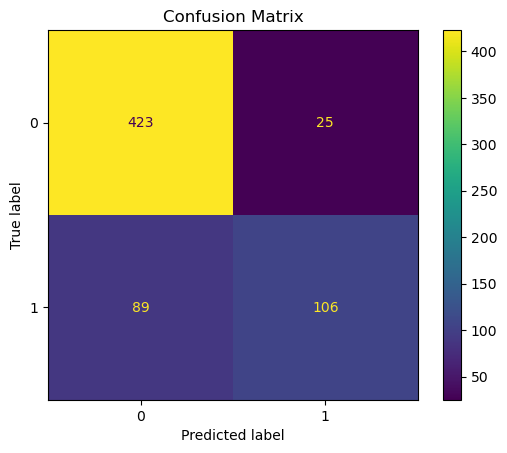

In [12]:
ConfusionMatrixDisplay.from_predictions(target_test, predictions_test)

plt.title("Confusion Matrix")
plt.show()

Sanity Check

To verify that the model has learned meaningful patterns, a sanity check will be performed by comparing the model’s performance to a simple baseline model that always predicts the most common class.

If the machine learning model performs significantly better than this baseline, it confirms that the model is making useful predictions.

In [13]:
# Sanity Check
# Let's compare with a simple baseline that predicts the most frequent class (0)
sanity_predictions = [0] * len(target_test)
sanity_accuracy = accuracy_score(target_test, sanity_predictions)

print()
print('Sanity check accuracy:', sanity_accuracy)


Sanity check accuracy: 0.6967340590979783


Conclusion

In this project, several machine learning models were developed to recommend a mobile plan based on subscriber usage behavior. The dataset was split into training, validation, and test sets to ensure proper model evaluation.

After testing multiple algorithms and tuning hyperparameters, the Random Forest model produced the best performance, achieving an accuracy above the required threshold of 0.75. The model was then evaluated on the test set to confirm its effectiveness.

A sanity check demonstrated that the selected model outperforms a simple baseline prediction, confirming that it successfully learned patterns within the data.

The final model can help Megaline recommend the most appropriate plan to customers based on their usage behavior, improving both customer satisfaction and service optimization.